In [1]:
import numpy as np
from simulation import Simulation

In [2]:
sim = Simulation(threads=10)

Converting sequence "synchrotron":   0%|          | 0/1990 [00:00<?, ?it/s]

In [3]:
s_list = np.linspace(0, sim.length, 26, endpoint=False)
strength_list = 1e-3 * np.cos(13 * 2*np.pi * s_list / sim.line.get_length())
#sim.add_dipole(strength=strength_list, s=s_list, mode='skew') # normal

In [4]:
sim.set_up(n_particles = int(1e3),
          n_turns = 50,
          n_monitors = 100,
          nemitt_x_0=2e-8,
          nemitt_y_0=2e-8)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


Slicing line:   0%|          | 0/3980 [00:00<?, ?it/s]

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


In [5]:
sim.run(spacecharge=False, beam_intensity=2e11, n_interactions=100, indirect_spacecharge=False)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


In [6]:
sim.save('new_tune')

/home/rsimpson/MPhys Project/Code/Accelerator Simulation/simulation.py:186: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['W_matrix'], dtype='str')]

  df_twiss.to_hdf(f'data/{filename}.h5', key='twiss_data',


File saved at data/new_tune


In [11]:
print(sim.particle_on_co.x)

print(np.mean(analysis.x[:,0]))

[-2.8338728e-12]
-2.833872789209657e-12


PyHEADTAIL v1.16.5


/home/rsimpson/anaconda3/envs/Xtrack/lib/python3.13/site-packages/tables/attributeset.py:322: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=()`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  value = self._g_getattr(self._v_node, name)


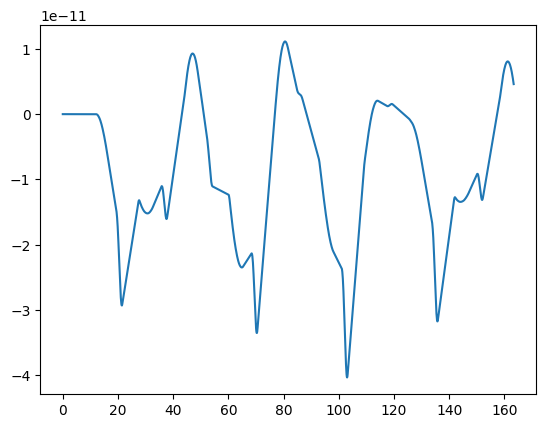

In [8]:
import numpy as np
import matplotlib.pyplot as plt 

from analysis import Analysis
analysis= Analysis('new_tune')
#analysis.tune_histogram(x_lims=(4.2,4.4), y_lims=(3.7,3.9))
#analysis.plot_ensemble_fft_spectrum('x')
#analysis.plot_ensemble_fft_spectrum('y')
plt.plot(analysis.df_twiss.s, analysis.df_twiss.x)

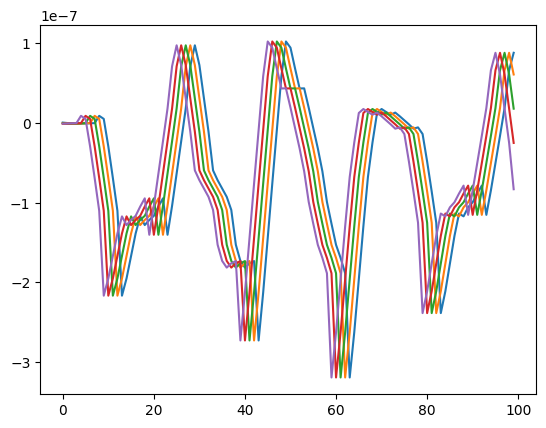

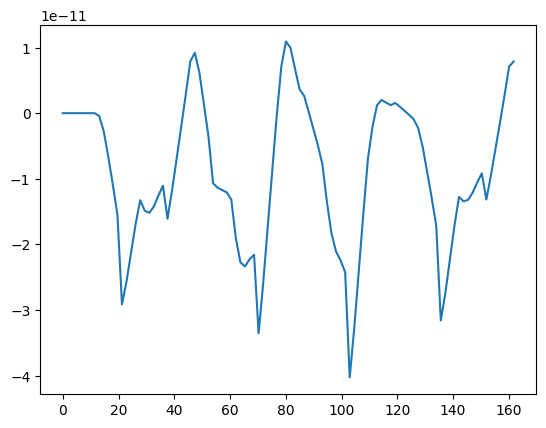

In [9]:
for n in range(5):
    plt.plot(np.mean(analysis.x, axis=0)[n:n+100])
plt.show()
mon_mask = analysis.df_twiss['name'].str.contains('mon')
df_mon = analysis.df_twiss[mon_mask]

plt.plot(df_mon.s, df_mon.x)

AttributeError: 'Analysis' object has no attribute 'sigma_x'

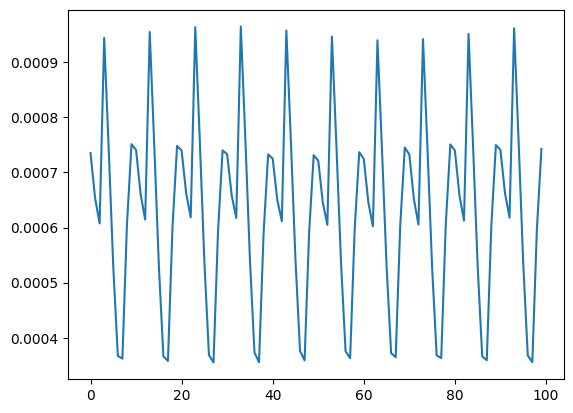

In [12]:
plt.plot(np.std(analysis.x, axis=0)[0:100])
plt.plot(analysis.sigma_x)
plt.show()
plt.plot(np.std(analysis.y, axis=0)[0:100])
plt.plot(analysis.sigma_y)
plt.show()